# R2：PyTorch 线性回归训练循环

目标：使用 `torch.nn` 与 `torch.optim` 训练一个线性回归模型，完整对应“前向计算 → 损失 → 反向传播 → 更新参数”的训练循环。

本节不要求手写梯度；重点是读懂每一行代码在训练流程中的位置。

In [1]:
import matplotlib.pyplot as plt
import torch

# 固定随机数，使每次运行得到相同的模拟数据和初始参数。
torch.manual_seed(42)

## 1. 准备一份带噪声的训练数据

真实关系近似为：

$$
y=2x+1+\text{noise}
$$

模型不知道公式中的 2 和 1，需要从样本中学出权重与偏置。

X shape: torch.Size([100, 1])
y shape: torch.Size([100, 1])


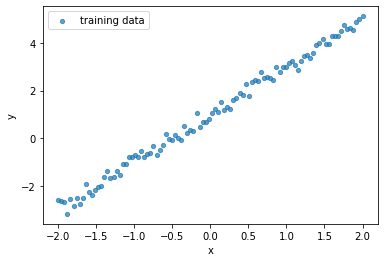

In [2]:
# 100 个样本，每个样本只有一个输入特征，因此 X 的形状是 (100, 1)。
X = torch.linspace(-2, 2, 100).reshape(-1, 1)
noise = 0.2 * torch.randn(100, 1)
y = 2 * X + 1 + noise

print('X shape:', X.shape)
print('y shape:', y.shape)

plt.scatter(X.numpy(), y.numpy(), s=18, alpha=0.7, label='training data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## 2. 定义模型、损失函数和优化器

- `nn.Linear(1, 1)`：一个输入特征、一个输出值；内部自动保存待学习的 weight 和 bias。
- `MSELoss()`：均方误差。
- `SGD(...)`：随机梯度下降优化器；它会根据 `.grad` 更新模型中的参数。

In [3]:
import torch.nn as nn

# 模型内部包含两个可学习参数：weight 和 bias。
model = nn.Linear(in_features=1, out_features=1)
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

print('训练前参数：')
for name, parameter in model.named_parameters():
    print(name, parameter.detach().item())

训练前参数：
weight 0.1563711166381836
bias -0.8799213171005249


## 3. 完整训练循环

每轮都严格按以下顺序：

1. `optimizer.zero_grad()`：清掉上一轮累积的梯度。
2. `prediction = model(X)`：前向计算。
3. `loss = loss_function(prediction, y)`：计算损失。
4. `loss.backward()`：自动计算所有参数的梯度。
5. `optimizer.step()`：用梯度更新参数。

In [4]:
epochs = 200
loss_history = []

for epoch in range(epochs):
    # 1. 梯度默认会累积，因此每轮开始前先清空。
    optimizer.zero_grad()

    # 2. 前向计算：调用模型得到预测值。
    prediction = model(X)

    # 3. 计算预测值与真实值的 MSE。
    loss = loss_function(prediction, y)

    # 4. 反向传播：计算 weight 与 bias 的梯度，写入它们的 .grad。
    loss.backward()

    # 5. 优化器按学习率和梯度更新参数。
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f'epoch {epoch + 1:>3}: loss = {loss.item():.4f}')

epoch  50: loss = 0.0386
epoch 100: loss = 0.0385
epoch 150: loss = 0.0385
epoch 200: loss = 0.0385



训练后参数：
weight 1.9970520734786987
bias 1.011952519416809


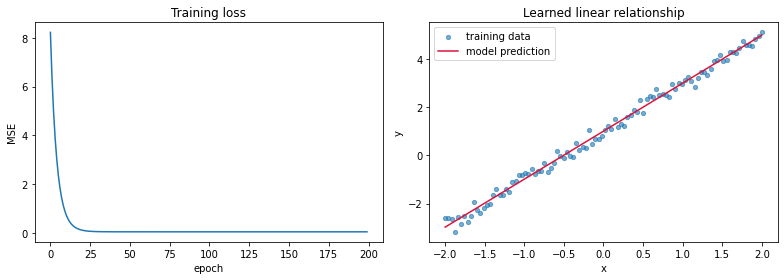

In [5]:
print('\n训练后参数：')
for name, parameter in model.named_parameters():
    print(name, parameter.detach().item())

# 画训练损失和最终拟合直线。
with torch.no_grad():
    final_prediction = model(X)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_history)
axes[0].set(title='Training loss', xlabel='epoch', ylabel='MSE')

axes[1].scatter(X.numpy(), y.numpy(), s=18, alpha=0.6, label='training data')
axes[1].plot(X.numpy(), final_prediction.numpy(), color='crimson', label='model prediction')
axes[1].set(title='Learned linear relationship', xlabel='x', ylabel='y')
axes[1].legend()
plt.tight_layout()
plt.show()

## 本节结论

训练后 weight 应接近 2、bias 应接近 1，但不必完全相同，因为数据含噪声。下一节会把同一训练流程从一个特征扩展到真实数据的多个特征，并开始使用 `Dataset` 与 `DataLoader` 分批训练。